https://docs.google.com/document/d/1L3bMxMfdZkFkJICjw4CGQFvYGI-5oDsWBcGDyUrJtf8/edit?tab=t.0#heading=h.xpcyijp2m12g - link para enunciado

In [4]:
import numpy as np
import pandas as pd
import os

pasta = '/content/drive/MyDrive/REDES_CHAL_2S2/' #importando planilha
print(os.listdir(pasta))

['datatran2025.csv']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = pasta + 'datatran2025.csv' #puxando a planilha
df = pd.read_csv(file_path, encoding='latin-1', sep=';')

In [5]:
# PRE-PROCESSAMENTO

df = df.drop(columns=['id', 'veiculos', 'delegacia', 'uop', 'ignorados', 'regional', 'uso_solo'])
df = df.dropna() # dropando nulls
df['data_inversa'] = pd.to_datetime(df['data_inversa'], errors='coerce')

In [6]:
# Extrair Ano e Mês
df['ano_mes'] = df['data_inversa'].dt.to_period('M')

# Transformando os dados em sequência temporal
monthly_agg = df.groupby('ano_mes').agg(
    n_acidentes=('data_inversa', 'count'), # Contar o número de linhas (acidentes) por mês
    n_mortos=('mortos', 'sum'),
    n_feridos=('feridos', 'sum'),
    n_feridos_leves=('feridos_leves', 'sum'),
    n_feridos_graves=('feridos_graves', 'sum'),
    n_ilesos=('ilesos', 'sum')

).reset_index()

# Converter 'ano_mes' de Period para string ou timestamp, se necessário para visualização ou outros passos
monthly_agg['ano_mes'] = monthly_agg['ano_mes'].astype(str)

display(monthly_agg.head())
display(monthly_agg.info())

,ano_mes,n_acidentes,n_mortos,n_feridos,n_feridos_leves,n_feridos_graves,n_ilesos
0,2025-01,5523,417,6910,5365,1545,6337
1,2025-02,5283,412,5967,4596,1371,5335
2,2025-03,5958,462,6781,5184,1597,5988
3,2025-04,5782,495,6672,5072,1600,6329
4,2025-05,6090,574,6827,5125,1702,6090


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ano_mes           8 non-null      object
 1   n_acidentes       8 non-null      int64 
 2   n_mortos          8 non-null      int64 
 3   n_feridos         8 non-null      int64 
 4   n_feridos_leves   8 non-null      int64 
 5   n_feridos_graves  8 non-null      int64 
 6   n_ilesos          8 non-null      int64 
dtypes: int64(6), object(1)
memory usage: 580.0+ bytes


None

In [7]:
# Escolhi o target como sendo severo/não severno ou seja, binário.
df["severo"] = ((df["mortos"] > 0) | (df["feridos_graves"] > 0)).astype(int)


In [8]:
# Criando as janelas para treinar o modelo LSTM
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(df["severo"].values, window_size=12)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(12, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1888/1888 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.7113 - loss: 0.6048 - val_accuracy: 0.7216 - val_loss: 0.5948
Epoch 2/50
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7119 - loss: 0.6007 - val_accuracy: 0.7216 - val_loss: 0.5927
Epoch 3/50
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.7150 - loss: 0.5980 - val_accuracy: 0.7216 - val_loss: 0.5915
Epoch 4/50
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7152 - loss: 0.5975 - val_accuracy: 0.7216 - val_loss: 0.5914
Epoch 5/50
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7204 - loss: 0.5925 - val_accuracy: 0.7216 - val_loss: 0.5919
Epoch 6/50
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.7160 - loss: 0.5968 - val_accuracy: 0.7216 - val_loss: 0.5914
Epoch 7/50
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.7168 - loss: 0.5962 - val_accuracy: 0.7216 - val_loss: 0.5921
Epoch 8/50
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7161 - loss: 0.59

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC (test):", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
ROC-AUC (test): 0.5180497973961136
              precision    recall  f1-score   support

           0       0.72      1.00      0.83      6762
           1       0.00      0.00      0.00      2674

    accuracy                           0.72      9436
   macro avg       0.36      0.50      0.42      9436
weighted avg       0.51      0.72      0.60      9436

[[6762    0]
 [2674    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


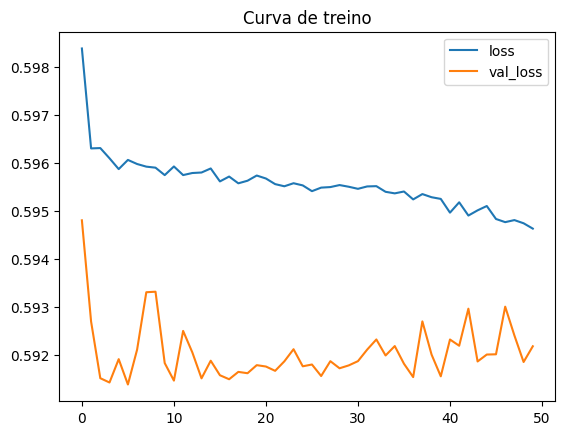

In [17]:
import matplotlib.pyplot as plt
# Gerando gráficos
plt.figure()
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend(); plt.title("Curva de treino"); plt.show()
model.save("sompo_lstm.keras")  # salvando modelo.keras